# Табличная модель

Регрессия среднего рейтинга карточки по её атрибутам: цена, число фото, бренд, категория, число отзывов, число цветов, длина названия. Сплиты с этапа 3 (7309 / 1045 / 2089), метрики RMSE / MAE, seed 42. Каждый запуск — отдельный run в DagsHub: гиперпараметры, метрики по эпохам, кривые обучения и веса модели

Выводы словами — в `docs/tabular_mlp.md`

Целевая очень узкая, почти весь каталог — карточки 4.5–5.0, поэтому даже константа даёт RMSE около 0.15 и борьба идёт за сотые. Ценность модели — не точное среднее, а ранжирование редких проблемных карточек

In [1]:
import json
import sys
import warnings

warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from torch import nn
from torch.utils.data import DataLoader, Dataset

sys.path.append("..")
from src.preprocess import build_tabular_preprocessor
from src.utils import ROOT, get_device, load_config, set_seed, setup_mlflow

cfg = load_config()
t = cfg["tabular"]
seed = cfg["random_seed"]
target = t["target"]
device = get_device()
setup_mlflow(cfg["mlflow"]["experiment_tabular"])
TAGS = {"mlflow.source.name": "notebooks/tabular_mlp.ipynb"}
MODELS = ROOT / "models"
print("устройство:", device)

устройство: mps


## Данные и признаки

Кодирование с 3 этапа: log1p + StandardScaler для цены и числа отзывов, скейлинг остальных чисел, one-hot категории, target encoding бренда. Для train обязательно `fit_transform` — TargetEncoder делает KFold cross-fitting только в нём, а `fit` + `transform` закодировал бы train полными статистиками, и таргет каждой строки утёк бы в её же признак. Val и test кодируются `transform` по статистикам train. Для эмбеддинг-конфигурации бренд дополнительно кодируется индексом, 0 — бренды, которых нет в train

In [2]:
PROC = ROOT / cfg["paths"]["data_processed"]
train = pd.read_parquet(PROC / "tabular_train.parquet")
val = pd.read_parquet(PROC / "tabular_val.parquet")
test = pd.read_parquet(PROC / "tabular_test.parquet")

pre = build_tabular_preprocessor(cfg)
X_train = pre.fit_transform(train, train[target])
names = pre.get_feature_names_out()
no_brand_cols = [i for i, n in enumerate(names) if not n.startswith("brand__")]
vocab = {b: i + 1 for i, b in enumerate(sorted(train["brand"].unique()))}
n_brands = len(vocab) + 1


def pack_part(X, df):
    if hasattr(X, "toarray"):
        X = X.toarray()
    X = X.astype(np.float32)
    brand_idx = np.array([vocab.get(b, 0) for b in df["brand"]], dtype=np.int64)
    y = df[target].to_numpy().astype(np.float32)
    return {"X": X, "X_no_brand": X[:, no_brand_cols], "brand": brand_idx, "y": y}


def make_part(df):
    return pack_part(pre.transform(df), df)


parts = {"train": pack_part(X_train, train), "val": make_part(val)}
print("train:", parts["train"]["X"].shape, "| val:", parts["val"]["X"].shape, "| брендов:", len(vocab))

train: (7309, 9) | val: (1045, 9) | брендов: 1137


## Baseline без сети

Точка отсчёта: константа, линейная модель и градиентный бустинг. Сеть имеет смысл, только если обходит бустинг

In [3]:
def rmse_mae(y_true, y_pred):
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    return rmse, mae


set_seed(seed)
baselines = {
    "baseline_mean": DummyRegressor(strategy="mean"),
    "baseline_ridge": Ridge(alpha=1.0, random_state=seed),
    "baseline_gb": HistGradientBoostingRegressor(random_state=seed),
}
rows = []
for name, model in baselines.items():
    model.fit(parts["train"]["X"], parts["train"]["y"])
    rmse, mae = rmse_mae(parts["val"]["y"], model.predict(parts["val"]["X"]))
    with mlflow.start_run(run_name=name, tags=TAGS):
        mlflow.log_params({"model": name, "seed": seed})
        mlflow.log_metrics({"val_rmse": rmse, "val_mae": mae})
        path = MODELS / f"{name}.joblib"
        joblib.dump(model, path)
        mlflow.log_artifact(path)
    rows.append({"модель": name, "val_rmse": round(rmse, 4), "val_mae": round(mae, 4)})
pd.DataFrame(rows)

🏃 View run baseline_mean at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/f8a73555802c49879a41d29f6203ad1a
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
🏃 View run baseline_ridge at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/1590e40bccd44c17bb53a632846af5bb
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
🏃 View run baseline_gb at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/3e7c96b41bc14213baa8bef572efd411
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1


,модель,val_rmse,val_mae
0,baseline_mean,0.1399,0.1065
1,baseline_ridge,0.1298,0.0916
2,baseline_gb,0.1295,0.0888


## MLP

Dataset отдаёт признаки, индекс бренда и таргет. Обычный MLP индекс игнорирует, EmbMLP подаёт его в `nn.Embedding`. Обучение: Adam, MSE-лосс, batch 64, до 50 эпох, early stopping по val RMSE с patience 10, лучшие веса восстанавливаются

In [5]:
ACTIVATIONS = {"relu": nn.ReLU, "gelu": nn.GELU, "selu": nn.SELU}


class TabularDataset(Dataset):
    def __init__(self, X, brand, y):
        self.X = torch.from_numpy(X)
        self.brand = torch.from_numpy(brand)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.brand[i], self.y[i]


class MLP(nn.Module):
    def __init__(self, in_dim, hidden, act="relu", dropout=0.0, batchnorm=False):
        super().__init__()
        layers = []
        for h in hidden:
            layers.append(nn.Linear(in_dim, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(ACTIVATIONS[act]())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, brand=None):
        return self.net(x).squeeze(1)


class EmbMLP(nn.Module):
    def __init__(self, num_dim, n_brands, emb_dim, hidden, act="relu", dropout=0.0, batchnorm=False):
        super().__init__()
        self.emb = nn.Embedding(n_brands, emb_dim, padding_idx=0)
        self.mlp = MLP(num_dim + emb_dim, hidden, act=act, dropout=dropout, batchnorm=batchnorm)

    def forward(self, x, brand):
        return self.mlp(torch.cat([x, self.emb(brand)], dim=1))

In [6]:
def make_loaders(emb):
    key = "X_no_brand" if emb else "X"
    g = torch.Generator()
    g.manual_seed(seed)
    train_ds = TabularDataset(parts["train"][key], parts["train"]["brand"], parts["train"]["y"])
    val_ds = TabularDataset(parts["val"][key], parts["val"]["brand"], parts["val"]["y"])
    train_loader = DataLoader(train_ds, batch_size=t["batch_size"], shuffle=True, generator=g)
    val_loader = DataLoader(val_ds, batch_size=512)
    return train_loader, val_loader


def predict(model, part, emb):
    key = "X_no_brand" if emb else "X"
    ds = TabularDataset(part[key], part["brand"], part["y"])
    loader = DataLoader(ds, batch_size=512)
    model.eval()
    preds = []
    with torch.no_grad():
        for X, b, _ in loader:
            preds.append(model(X.to(device), b.to(device)).cpu().numpy())
    return np.concatenate(preds)


def train_model(model, train_loader, val_loader, lr, weight_decay):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    best_rmse = float("inf")
    best_mae = None
    best_epoch = 0
    best_state = None
    history = []
    bad = 0
    for epoch in range(1, t["epochs"] + 1):
        model.train()
        total = 0.0
        n = 0
        for X, b, y in train_loader:
            opt.zero_grad()
            loss = loss_fn(model(X.to(device), b.to(device)), y.to(device))
            loss.backward()
            opt.step()
            total += loss.item() * len(y)
            n += len(y)
        train_loss = total / n
        model.eval()
        preds = []
        ys = []
        with torch.no_grad():
            for X, b, y in val_loader:
                preds.append(model(X.to(device), b.to(device)).cpu().numpy())
                ys.append(y.numpy())
        val_rmse, val_mae = rmse_mae(np.concatenate(ys), np.concatenate(preds))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_rmse": val_rmse, "val_mae": val_mae})
        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_mae = val_mae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= t["patience"]:
                break
    model.load_state_dict(best_state)
    return {"val_rmse": best_rmse, "val_mae": best_mae, "epoch": best_epoch, "state": best_state}, history

## Четыре конфигурации

Значимо разные по глубине, активациям и регуляризации: маленькая сеть как точка отсчёта, глубокая с dropout и weight decay, BatchNorm + GELU, и эмбеддинг бренда — подход не из лекций: вместо target encoding бренд подаётся в `nn.Embedding` (`padding_idx=0`, чтобы бренды не из train получали нейтральный нулевой вектор), и сеть учит представление бренда сама, как в рекомендательных системах

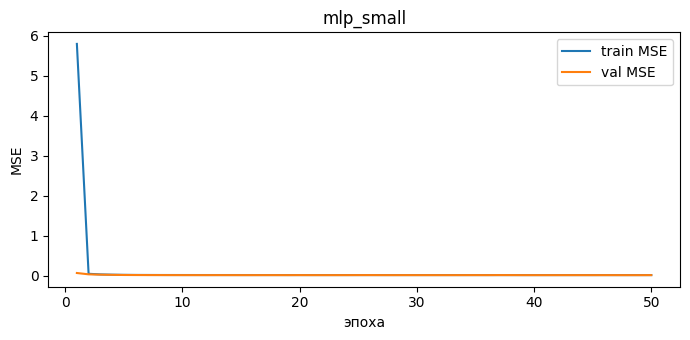

🏃 View run mlp_small at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/e4a39d733c5b41e38af787c4d681a940
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
mlp_small | val rmse: 0.1274 | val mae: 0.0875 | эпоха: 49


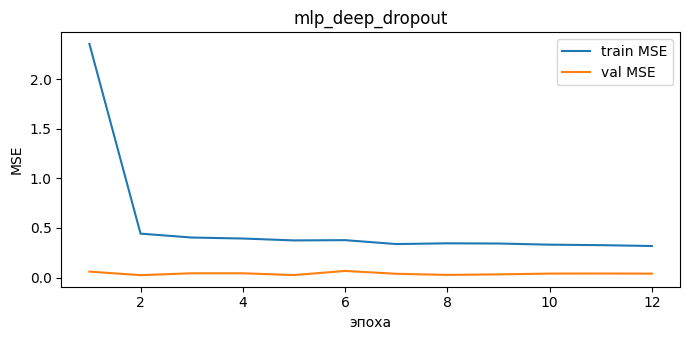

🏃 View run mlp_deep_dropout at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/7ce321d2426d477ca9515c03557ec5d6
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
mlp_deep_dropout | val rmse: 0.1537 | val mae: 0.1186 | эпоха: 2


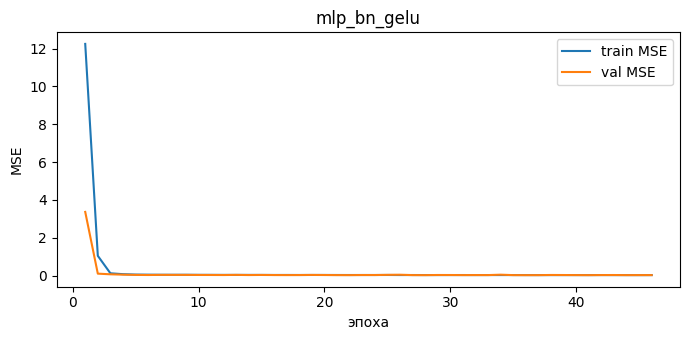

🏃 View run mlp_bn_gelu at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/8a100586217442d5b89f884612a37c9a
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
mlp_bn_gelu | val rmse: 0.1432 | val mae: 0.1088 | эпоха: 36


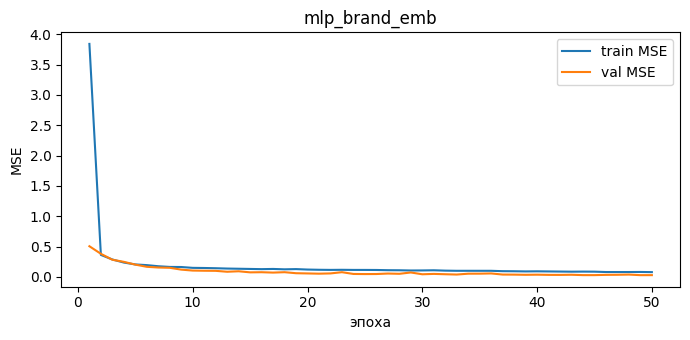

🏃 View run mlp_brand_emb at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/eda5b1221ffc4f2fb69e67b99cfd0b25
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
mlp_brand_emb | val rmse: 0.172 | val mae: 0.1204 | эпоха: 49


In [7]:
CONFIGS = [
    {"name": "mlp_small", "hidden": [64], "act": "relu", "dropout": 0.0,
     "batchnorm": False, "weight_decay": 0.0, "emb": False},
    {"name": "mlp_deep_dropout", "hidden": [256, 128, 64], "act": "relu", "dropout": 0.2,
     "batchnorm": False, "weight_decay": 0.0001, "emb": False},
    {"name": "mlp_bn_gelu", "hidden": [128, 64], "act": "gelu", "dropout": 0.0,
     "batchnorm": True, "weight_decay": 0.0, "emb": False},
    {"name": "mlp_brand_emb", "hidden": [128, 64], "act": "relu", "dropout": 0.1,
     "batchnorm": False, "weight_decay": 0.0, "emb": True, "emb_dim": 16},
]


def build_model(c, in_dim):
    if c["emb"]:
        return EmbMLP(in_dim, n_brands, c["emb_dim"], c["hidden"],
                      act=c["act"], dropout=c["dropout"], batchnorm=c["batchnorm"])
    return MLP(in_dim, c["hidden"], act=c["act"],
               dropout=c["dropout"], batchnorm=c["batchnorm"])


def run_one(c, run_name, lr, show=False):
    set_seed(seed)
    train_loader, val_loader = make_loaders(c["emb"])
    key = "X_no_brand" if c["emb"] else "X"
    model = build_model(c, parts["train"][key].shape[1])
    with mlflow.start_run(run_name=run_name, tags=TAGS):
        mlflow.log_params({
            "hidden": str(c["hidden"]), "act": c["act"], "dropout": c["dropout"],
            "batchnorm": c["batchnorm"], "weight_decay": c["weight_decay"],
            "emb": c["emb"], "emb_dim": c.get("emb_dim", 0), "lr": lr,
            "batch_size": t["batch_size"], "patience": t["patience"], "seed": seed,
        })
        best, history = train_model(model, train_loader, val_loader, lr, c["weight_decay"])
        for h in history:
            mlflow.log_metrics(
                {"train_loss": h["train_loss"], "val_rmse": h["val_rmse"], "val_mae": h["val_mae"]},
                step=h["epoch"],
            )
        mlflow.log_metrics({"best_val_rmse": best["val_rmse"], "best_val_mae": best["val_mae"],
                            "best_epoch": best["epoch"]})
        epochs = [h["epoch"] for h in history]
        plt.figure(figsize=(7, 3.5))
        plt.plot(epochs, [h["train_loss"] for h in history], label="train MSE")
        plt.plot(epochs, [h["val_rmse"] ** 2 for h in history], label="val MSE")
        plt.xlabel("эпоха")
        plt.ylabel("MSE")
        plt.title(run_name)
        plt.legend()
        plt.tight_layout()
        path = MODELS / "curves.png"
        plt.savefig(path)
        mlflow.log_artifact(path)
        if show:
            plt.show()
        else:
            plt.close()
        model_path = MODELS / f"{run_name}.pt"
        torch.save(best["state"], model_path)
        mlflow.log_artifact(model_path)
    print(run_name, "| val rmse:", round(best["val_rmse"], 4),
          "| val mae:", round(best["val_mae"], 4), "| эпоха:", best["epoch"])
    return best


results = {}
for c in CONFIGS:
    results[c["name"]] = (c, t["lr"], run_one(c, c["name"], t["lr"], show=True))

Выиграла самая маленькая сеть: данных 7.3 тыс. строк и 9 признаков, ёмкость глубокой сети не во что вложить. mlp_deep_dropout лучшую val-метрику показала уже на 2-й эпохе — dropout 0.2 здесь слишком грубая регуляризация. BatchNorm + GELU хуже простого ReLU: статистики по батчу 64 шумные. Эмбеддинг бренда переобучается — 1137 брендов дают 18 тыс. параметров только в эмбеддинге, target encoding использует ту же информацию экономнее

## Подбор гиперпараметров

Сетка вокруг лучшей архитектуры: lr из {0.0003, 0.001, 0.003} × weight decay из {0, 0.0001}. Перебираем именно это, потому что lr — главный параметр оптимизации, а weight decay — единственная регуляризация, у которой был шанс помочь маленькой сети

In [8]:
GRID_LR = [0.0003, 0.001, 0.003]
GRID_WD = [0.0, 0.0001]

best_arch = min(results.values(), key=lambda r: r[2]["val_rmse"])[0]
print("лучшая архитектура:", best_arch["name"])
for lr in GRID_LR:
    for wd in GRID_WD:
        if lr == t["lr"] and wd == best_arch["weight_decay"]:
            continue
        c = dict(best_arch)
        c["weight_decay"] = wd
        run_name = f"{c['name']}_lr{lr}_wd{wd}"
        results[run_name] = (c, lr, run_one(c, run_name, lr))

лучшая архитектура: mlp_small
🏃 View run mlp_small_lr0.0003_wd0.0 at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/c63b8cbdeee54678977033b0f8340d97
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
mlp_small_lr0.0003_wd0.0 | val rmse: 0.1289 | val mae: 0.0909 | эпоха: 40
🏃 View run mlp_small_lr0.0003_wd0.0001 at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/07bed271cc4a42aa9ae0d00ada8dc9d1
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
mlp_small_lr0.0003_wd0.0001 | val rmse: 0.1291 | val mae: 0.0932 | эпоха: 49
🏃 View run mlp_small_lr0.001_wd0.0001 at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/09e1b3f0e9d04a31968a33489ea54270
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
mlp_small_lr0.001_wd0.0001 | val rmse: 0.1282 | val mae: 0.0892 | эпоха: 22
🏃 View run mlp_small_lr0.003_wd0.0 at: https://dagshub.com/nazin.v

In [9]:
summary = pd.DataFrame(
    [{"запуск": name, "val_rmse": round(b["val_rmse"], 4), "val_mae": round(b["val_mae"], 4), "эпоха": b["epoch"]}
     for name, (c, lr, b) in results.items()]
).sort_values("val_rmse").reset_index(drop=True)
summary

,запуск,val_rmse,val_mae,эпоха
0,mlp_small,0.1274,0.0875,49
1,mlp_small_lr0.001_wd0.0001,0.1282,0.0892,22
2,mlp_small_lr0.003_wd0.0001,0.1286,0.0883,12
3,mlp_small_lr0.003_wd0.0,0.1287,0.0884,12
4,mlp_small_lr0.0003_wd0.0,0.1289,0.0909,40
5,mlp_small_lr0.0003_wd0.0001,0.1291,0.0932,49
6,mlp_bn_gelu,0.1432,0.1088,36
7,mlp_deep_dropout,0.1537,0.1186,2
8,mlp_brand_emb,0.1720,0.1204,49


In [10]:
best_name = min(results, key=lambda k: results[k][2]["val_rmse"])
c_best, lr_best, best = results[best_name]
torch.save(best["state"], MODELS / "mlp_best.pt")
joblib.dump(pre, MODELS / "tabular_preprocessor.joblib")
meta = dict(c_best)
meta.update({"run_name": best_name, "lr": lr_best, "val_rmse": best["val_rmse"],
             "val_mae": best["val_mae"], "epoch": best["epoch"],
             "vocab": vocab, "no_brand_cols": no_brand_cols})
with open(MODELS / "mlp_best.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False)
print("лучший запуск:", best_name, "| val rmse:", round(best["val_rmse"], 4))

лучший запуск: mlp_small | val rmse: 0.1274


Разброс по сетке в пределах двух тысячных RMSE — архитектура устойчива к гиперпараметрам.
Маленький lr не успевает за 50 эпох, большой быстро сходится, но чуть менее точно

## Финальная оценка на test

In [11]:
key = "X_no_brand" if c_best["emb"] else "X"
model = build_model(c_best, parts["train"][key].shape[1])
model.load_state_dict(torch.load(MODELS / "mlp_best.pt", weights_only=True))
model.to(device)

p_test = make_part(test)
preds = predict(model, p_test, c_best["emb"])
test_rmse, test_mae = rmse_mae(p_test["y"], preds)
mean_pred = np.full(len(test), train[target].mean(), dtype=np.float32)
mean_rmse, mean_mae = rmse_mae(p_test["y"], mean_pred)
gb_rmse, gb_mae = rmse_mae(p_test["y"], baselines["baseline_gb"].predict(p_test["X"]))
pd.DataFrame([
    {"модель": "среднее по train", "test_rmse": round(mean_rmse, 4), "test_mae": round(mean_mae, 4)},
    {"модель": "baseline_gb", "test_rmse": round(gb_rmse, 4), "test_mae": round(gb_mae, 4)},
    {"модель": best_name, "test_rmse": round(test_rmse, 4), "test_mae": round(test_mae, 4)},
])

,модель,test_rmse,test_mae
0,среднее по train,0.1511,0.1058
1,baseline_gb,0.1418,0.0871
2,mlp_small,0.1448,0.0900


## Важность признаков

Permutation importance лучшей модели на test: признак перемешивается 5 раз, смотрим средний прирост RMSE. Перемешиваются исходные столбцы до кодирования, поэтому one-hot категории и кодировка бренда учитываются как один признак

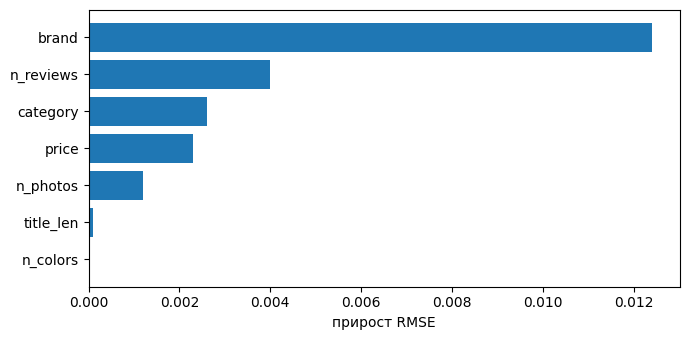

,признак,прирост_rmse
0,brand,0.0124
1,n_reviews,0.0040
2,category,0.0026
3,price,0.0023
4,n_photos,0.0012
5,title_len,0.0001
6,n_colors,0.0000


In [12]:
rng = np.random.default_rng(seed)
rows = []
for col in t["features"]:
    deltas = []
    for _ in range(5):
        shuffled = test.copy()
        shuffled[col] = rng.permutation(shuffled[col].to_numpy())
        p_shuf = make_part(shuffled)
        shuf_rmse, _ = rmse_mae(p_shuf["y"], predict(model, p_shuf, c_best["emb"]))
        deltas.append(shuf_rmse - test_rmse)
    rows.append({"признак": col, "прирост_rmse": round(float(np.mean(deltas)), 4)})
imp = pd.DataFrame(rows).sort_values("прирост_rmse", ascending=False).reset_index(drop=True)
imp.to_csv(MODELS / "permutation_importance.csv", index=False)
plt.figure(figsize=(7, 3.5))
plt.barh(imp["признак"][::-1], imp["прирост_rmse"][::-1])
plt.xlabel("прирост RMSE")
plt.tight_layout()
plt.show()
imp

In [13]:
with mlflow.start_run(run_name="final_test", tags=TAGS):
    mlflow.log_params({"model": best_name, "hidden": str(c_best["hidden"]), "act": c_best["act"],
                       "dropout": c_best["dropout"], "batchnorm": c_best["batchnorm"],
                       "weight_decay": c_best["weight_decay"], "emb": c_best["emb"],
                       "emb_dim": c_best.get("emb_dim", 0), "lr": lr_best, "seed": seed})
    mlflow.log_metrics({"test_rmse": test_rmse, "test_mae": test_mae,
                        "test_rmse_mean": mean_rmse, "test_mae_mean": mean_mae,
                        "test_rmse_baseline": gb_rmse, "test_mae_baseline": gb_mae,
                        "val_rmse": best["val_rmse"], "val_mae": best["val_mae"]})
    for name in ["mlp_best.pt", "mlp_best.json", "tabular_preprocessor.joblib", "permutation_importance.csv"]:
        mlflow.log_artifact(MODELS / name)
print("final_test залогирован")

🏃 View run final_test at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1/runs/e94956cd10284205a61bf3394bc49fd0
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/1
final_test залогирован


## Выводы

MLP корректно обучается и уверенно бьёт константу, но устойчивого преимущества над градиентным бустингом на 7 тыс. строк не даёт: по val сеть чуть впереди, на test чуть впереди бустинг, разницы в третьем знаке. Рейтинг почти целиком определяется тем, кто продаёт: бренд один даёт больше, чем все остальные признаки вместе, дальше — накопленное число отзывов. Косметика карточки (фото, цвета, длина названия) рейтинг не двигает — работать нужно с товаром и продавцом, а почему конкретно карточка падает в рейтинге, ответит текстовая модель по отзывам (этап 5). Полное сравнение — в `docs/tabular_mlp.md`